# Gráficos de flujo T - Track


los grafico con python porque no se por qué los archivos eps no se actualizaron con la nueva informacion, y solo tengo los archivos .out

In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from matplotlib.colors import LogNorm

In [2]:
def leer_ttrack_2d(archivo):

    archivo = Path(archivo)

    texto = archivo.read_text(
        encoding="utf-8",
        errors="ignore"
    )

    numero = (
        r"[-+]?(?:\d+(?:\.\d*)?|\.\d+)"
        r"(?:[EeDd][-+]?\d+)?"
    )

    def extraer(patron, tipo=float):

        match = re.search(
            patron,
            texto,
            flags=re.MULTILINE | re.IGNORECASE
        )

        if not match:
            raise ValueError(
                f"No se encontró: {patron}"
            )

        valor = match.group(1).replace("D", "E")

        return tipo(valor)

    match_plano = re.search(
        r"^\s*#?\s*axis\s*=\s*(xy|xz|yz)\b",
        texto,
        flags=re.MULTILINE | re.IGNORECASE
    )

    if not match_plano:
        raise ValueError(
            "No se encontró axis = xy, xz o yz."
        )

    plano = match_plano.group(1).lower()

    match_pagina = re.search(
        r"^\s*#?\s*newpage:\s*$",
        texto,
        flags=re.MULTILINE | re.IGNORECASE
    )

    inicio_pagina = (
        match_pagina.end()
        if match_pagina
        else 0
    )

    pagina = texto[inicio_pagina:]

    match_hc = re.search(
        r"^\s*hc:.*$",
        pagina,
        flags=re.MULTILINE | re.IGNORECASE
    )

    if not match_hc:
        raise ValueError(
            "No se encontró la línea hc de la matriz."
        )

    encabezado = pagina[:match_hc.start()]

    match_eje_horizontal = re.search(
        r"^\s*x:\s*([xyz])\s*\[cm\]",
        encabezado,
        flags=re.MULTILINE | re.IGNORECASE
    )

    match_eje_vertical = re.search(
        r"^\s*y:\s*([xyz])\s*\[cm\]",
        encabezado,
        flags=re.MULTILINE | re.IGNORECASE
    )

    if (
        not match_eje_horizontal
        or not match_eje_vertical
    ):
        raise ValueError(
            "No se pudieron identificar "
            "los ejes del gráfico."
        )

    eje_horizontal = (
        match_eje_horizontal
        .group(1)
        .lower()
    )

    eje_vertical = (
        match_eje_vertical
        .group(1)
        .lower()
    )

    def extraer_n(eje):

        patron = (
            rf"^\s*#?\s*n{eje}"
            rf"\s*=\s*(\d+)"
        )

        match = re.search(
            patron,
            texto,
            flags=re.MULTILINE | re.IGNORECASE
        )

        if not match:
            raise ValueError(
                f"No se encontró n{eje} "
                f"en {archivo.name}"
            )

        return int(match.group(1))

    n_horizontal = extraer_n(
        eje_horizontal
    )

    n_vertical = extraer_n(
        eje_vertical
    )

    match_rango_horizontal = re.search(
        rf"p:\s*xmin\(\s*({numero})\s*\)"
        rf"\s*xmax\(\s*({numero})\s*\)",
        encabezado,
        flags=re.IGNORECASE
    )

    match_rango_vertical = re.search(
        rf"p:\s*ymin\(\s*({numero})\s*\)"
        rf"\s*ymax\(\s*({numero})\s*\)",
        encabezado,
        flags=re.IGNORECASE
    )

    if match_rango_horizontal:

        minimo_horizontal = float(
            match_rango_horizontal
            .group(1)
            .replace("D", "E")
        )

        maximo_horizontal = float(
            match_rango_horizontal
            .group(2)
            .replace("D", "E")
        )

    else:

        minimo_horizontal = extraer(
            rf"^\s*#?\s*"
            rf"{eje_horizontal}min"
            rf"\s*=\s*({numero})"
        )

        maximo_horizontal = extraer(
            rf"^\s*#?\s*"
            rf"{eje_horizontal}max"
            rf"\s*=\s*({numero})"
        )

    if match_rango_vertical:

        minimo_vertical = float(
            match_rango_vertical
            .group(1)
            .replace("D", "E")
        )

        maximo_vertical = float(
            match_rango_vertical
            .group(2)
            .replace("D", "E")
        )

    else:

        minimo_vertical = extraer(
            rf"^\s*#?\s*"
            rf"{eje_vertical}min"
            rf"\s*=\s*({numero})"
        )

        maximo_vertical = extraer(
            rf"^\s*#?\s*"
            rf"{eje_vertical}max"
            rf"\s*=\s*({numero})"
        )

    match_limites = re.search(
        rf"set:\s*c3\[\s*({numero})\s*\]"
        rf"\s*c4\[\s*({numero})\s*\]",
        encabezado,
        flags=re.IGNORECASE
    )

    if match_limites:

        cmin = float(
            match_limites
            .group(1)
            .replace("D", "E")
        )

        cmax = float(
            match_limites
            .group(2)
            .replace("D", "E")
        )

    else:

        cmin = None
        cmax = None

    match_particula = re.search(
        r"^\s*#?\s*part\s*=\s*([^\n#]+)",
        texto,
        flags=re.MULTILINE | re.IGNORECASE
    )

    particula = (
        match_particula.group(1).strip()
        if match_particula
        else archivo.stem
    )

    inicio_datos = (
        inicio_pagina
        + match_hc.end()
    )

    match_fin = re.search(
        r"^\s*#\s*gshow\s*$"
        r"|^\s*newpage:\s*$"
        r"|^\s*#\s*newpage:\s*$"
        r"|^\s*#\s*Information for Restart",
        texto[inicio_datos:],
        flags=re.MULTILINE | re.IGNORECASE
    )

    if match_fin:

        fin_datos = (
            inicio_datos
            + match_fin.start()
        )

    else:

        fin_datos = len(texto)

    bloque_datos = texto[
        inicio_datos:fin_datos
    ]

    numeros = re.findall(
        numero,
        bloque_datos
    )

    valores = np.array([
        float(
            valor.replace("D", "E")
        )
        for valor in numeros
    ])

    cantidad = (
        n_horizontal
        * n_vertical
    )

    if valores.size < cantidad:

        raise ValueError(
            f"Se esperaban {cantidad} "
            f"valores, pero se encontraron "
            f"{valores.size}."
        )

    flujo = valores[
        :cantidad
    ].reshape(
        n_vertical,
        n_horizontal
    )

    positivos = flujo[
        flujo > 0
    ]

    if positivos.size == 0:
        raise ValueError(
            "El archivo no contiene "
            "valores positivos."
        )

    if cmin is None or cmin <= 0:
        cmin = positivos.min()

    if cmax is None or cmax <= 0:
        cmax = positivos.max()

    if cmax <= cmin:
        cmin = positivos.min()
        cmax = positivos.max()

    geometria = []

    match_gshow = re.search(
        r"^\s*#\s*gshow\s*$",
        texto[inicio_datos:],
        flags=re.MULTILINE | re.IGNORECASE
    )

    if match_gshow:

        inicio_gshow = (
            inicio_datos
            + match_gshow.end()
        )

        bloque_gshow = texto[
            inicio_gshow:
        ]

        match_colorbar = re.search(
            r"^\s*z:\s*xorg",
            bloque_gshow,
            flags=re.MULTILINE | re.IGNORECASE
        )

        if match_colorbar:

            bloque_gshow = (
                bloque_gshow[
                    :match_colorbar.start()
                ]
            )

        lineas = (
            bloque_gshow
            .splitlines()
        )

        i = 0

        while i < len(lineas):

            if (
                lineas[i]
                .strip()
                .lower()
                == "clip:"
            ):

                puntos = []
                i += 1

                while i < len(lineas):

                    partes = (
                        lineas[i]
                        .split()
                    )

                    if len(partes) != 2:
                        break

                    try:

                        coordenada_1 = float(
                            partes[0]
                            .replace("D", "E")
                        )

                        coordenada_2 = float(
                            partes[1]
                            .replace("D", "E")
                        )

                        puntos.append(
                            (
                                coordenada_1,
                                coordenada_2
                            )
                        )

                        i += 1

                    except ValueError:
                        break

                if len(puntos) >= 2:

                    geometria.append(
                        np.array(puntos)
                    )

            else:
                i += 1

    return {
        "archivo": archivo,
        "flujo": flujo,
        "plano": plano,
        "eje_horizontal": eje_horizontal,
        "eje_vertical": eje_vertical,
        "minimo_horizontal": minimo_horizontal,
        "maximo_horizontal": maximo_horizontal,
        "minimo_vertical": minimo_vertical,
        "maximo_vertical": maximo_vertical,
        "cmin": cmin,
        "cmax": cmax,
        "particula": particula,
        "geometria": geometria
    }


def graficar_ttrack_2d(
    archivo,
    mostrar_geometria=True,
    mostrar_bineado=False,
    tamano=None,
    barra="abajo"
):

    if isinstance(archivo, dict):
        datos = archivo
    else:
        datos = leer_ttrack_2d(
            archivo
        )

    es_error = (
        datos["archivo"]
        .stem
        .lower()
        .endswith("_err")
    )

    valores = np.ma.masked_less_equal(
        datos["flujo"],
        0
    )

    ancho_datos = (
        datos["maximo_horizontal"]
        - datos["minimo_horizontal"]
    )

    alto_datos = (
        datos["maximo_vertical"]
        - datos["minimo_vertical"]
    )

    proporcion = (
        ancho_datos
        / alto_datos
    )

    if tamano is None:

        if proporcion >= 2:
            tamano = (15, 5)

        elif proporcion <= 0.5:
            tamano = (6, 10)

        else:
            tamano = (8, 7)

    cmap = (
        plt.colormaps["jet"]
        .resampled(100)
        .copy()
    )

    cmap.set_bad("white")
    cmap.set_under("white")

    fig, ax = plt.subplots(
        figsize=tamano,
        constrained_layout=True
    )

    imagen = ax.imshow(
        valores,
        origin="upper",
        extent=[
            datos["minimo_horizontal"],
            datos["maximo_horizontal"],
            datos["minimo_vertical"],
            datos["maximo_vertical"]
        ],
        aspect="equal",
        interpolation="nearest",
        cmap=cmap,
        norm=LogNorm(
            vmin=datos["cmin"],
            vmax=datos["cmax"]
        )
    )

    if mostrar_geometria:

        for curva in datos["geometria"]:

            ax.plot(
                curva[:, 0],
                curva[:, 1],
                color="black",
                linewidth=0.7
            )

    if mostrar_bineado:

        n_vertical, n_horizontal = (
            datos["flujo"].shape
        )

        texto_bineado = (
            f"n{datos['eje_horizontal']} "
            f"= {n_horizontal}\n"
            f"n{datos['eje_vertical']} "
            f"= {n_vertical}"
        )

        ax.text(
            0.02,
            0.97,
            texto_bineado,
            transform=ax.transAxes,
            horizontalalignment="left",
            verticalalignment="top",
            bbox={
                "facecolor": "white",
                "edgecolor": "black",
                "alpha": 0.8,
                "boxstyle": "round,pad=0.3"
            }
        )

    if barra == "abajo":

        colorbar = fig.colorbar(
            imagen,
            ax=ax,
            orientation="horizontal",
            pad=0.16,
            fraction=0.10,
            aspect=45
        )

    elif barra == "derecha":

        colorbar = fig.colorbar(
            imagen,
            ax=ax,
            orientation="vertical",
            pad=0.03,
            fraction=0.05,
            aspect=30
        )

    else:

        raise ValueError(
            'barra debe ser '
            '"abajo" o "derecha".'
        )

    if es_error:

        colorbar.set_label(
            "Error relativo"
        )

        tipo = (
            "Error relativo del T-Track"
        )

    else:

        colorbar.set_label(
            "Flujo [1/cm²/source]"
        )

        tipo = "T-Track"

    ax.set_xlabel(
        f"{datos['eje_horizontal']} [cm]"
    )

    ax.set_ylabel(
        f"{datos['eje_vertical']} [cm]"
    )

    ax.set_title(
        f"{tipo} de "
        f"{datos['particula']} "
        f"en el plano "
        f"{datos['plano']}\n"
        f"{datos['archivo'].name}",
        pad=10
    )

    ax.set_xlim(
        datos["minimo_horizontal"],
        datos["maximo_horizontal"]
    )

    ax.set_ylim(
        datos["minimo_vertical"],
        datos["maximo_vertical"]
    )

    plt.show()

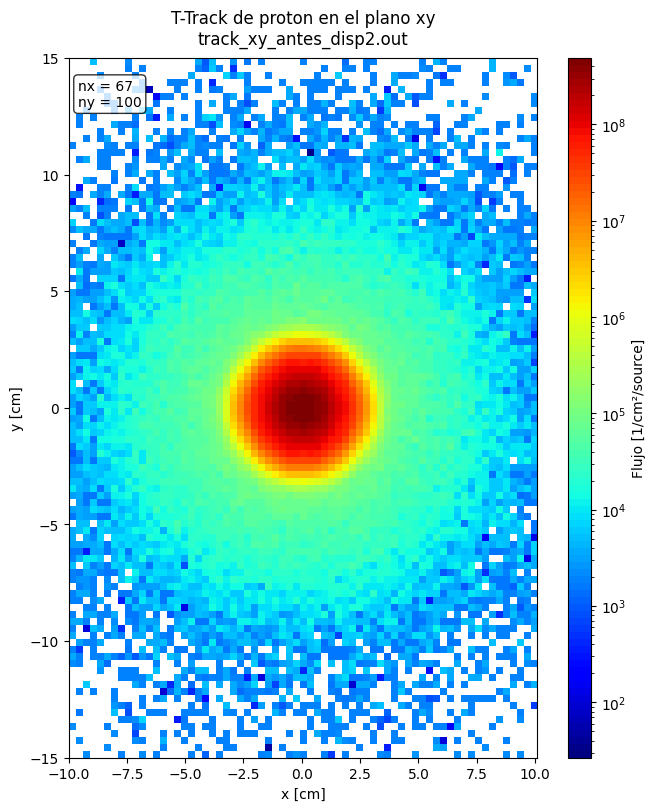

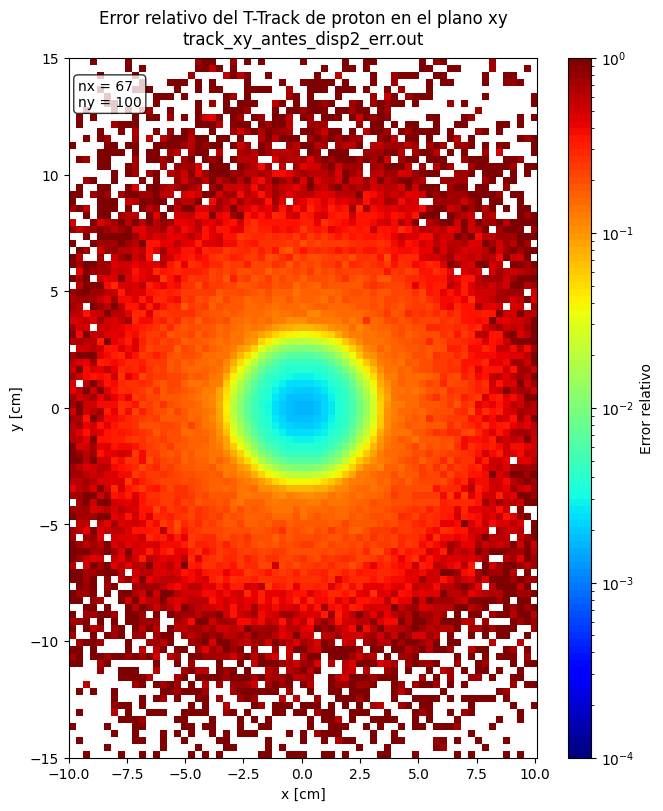

In [3]:
ruta = Path("../out")

track_xy_antes_disp2 = leer_ttrack_2d(
    ruta / "track_xy_antes_disp2.out"
)
track_xy_antes_disp2_error = leer_ttrack_2d(
    ruta / "track_xy_antes_disp2_err.out"
)

graficar_ttrack_2d(
    track_xy_antes_disp2,
    tamano=(7, 8),
    mostrar_bineado=True,
    barra="derecha"
)

graficar_ttrack_2d(
    track_xy_antes_disp2_error,
    tamano=(7, 8),
    mostrar_bineado=True,
    barra="derecha"
)

nx = 67
ny = 100

MÁXIMO DEL HAZ
Flujo máximo = 4.8980e+08
x del máximo = 0.050 cm
y del máximo = 0.150 cm

ANCHO DEL HAZ - FWHM
FWHM en X = 2.188 cm
  borde izquierdo = -1.093 cm
  borde derecho   = 1.095 cm

FWHM en Y = 2.145 cm
  borde inferior = -1.073 cm
  borde superior = 1.072 cm


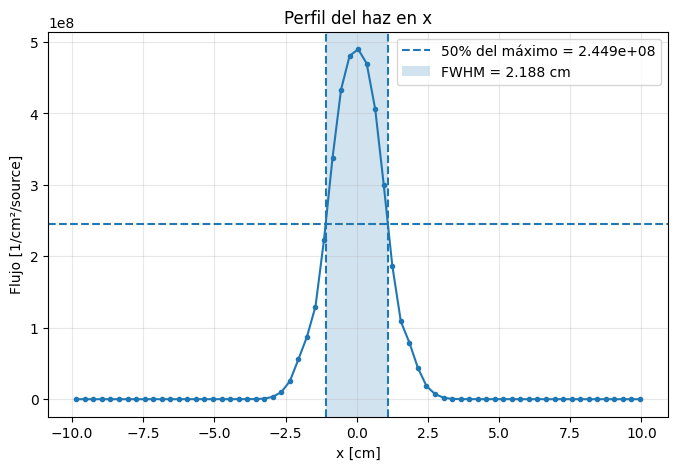

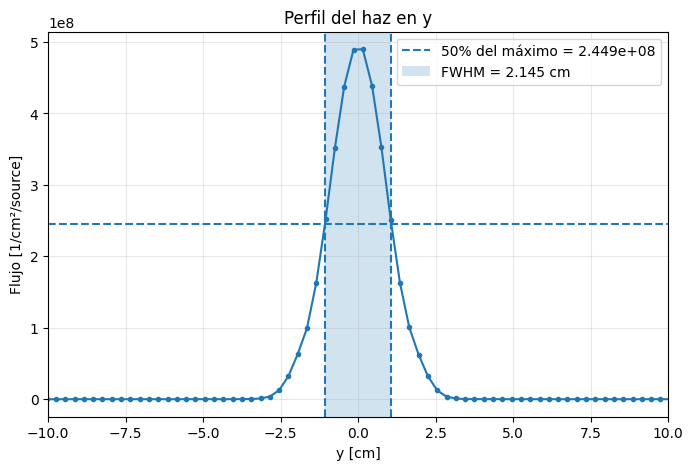

In [5]:

# ============================================================
# 1. ARCHIVO
# ============================================================

archivo = r"C:\phits\Laboratory-VII\ridge_filter_3\out\track_xy_antes_disp2.out"


# ============================================================
# 2. LEER EL ARCHIVO DE SALIDA DE PHITS
# ============================================================

def leer_ttrack(filename):

    with open(filename, "r") as f:
        lines = f.readlines()

    # Buscar la línea donde comienza la matriz de datos
    inicio = None

    for i, line in enumerate(lines):
        if line.strip().startswith("hc:"):
            inicio = i + 1
            break

    if inicio is None:
        raise ValueError("No se encontró la línea 'hc:' en el archivo.")

    # Buscar dimensiones nx y ny
    nx = None
    ny = None

    for line in lines:
        if "#  ny =" in line and "nx =" in line:
            match = re.search(r"ny\s*=\s*(\d+)\s+nx\s*=\s*(\d+)", line)

            if match:
                ny = int(match.group(1))
                nx = int(match.group(2))
                break

    if nx is None or ny is None:
        raise ValueError("No se pudieron encontrar nx y ny.")

    # Extraer números después de hc:
    datos = []

    for line in lines[inicio:]:
       
        # Si aparece otra sección, dejamos de leer
        if line.strip().startswith("#"):
            break

        # Extraer números científicos
        numeros = re.findall(
            r"[-+]?(?:\d+\.\d*|\.\d+|\d+)(?:[Ee][-+]?\d+)?",
            line
        )

        datos.extend([float(x) for x in numeros])

    datos = np.array(datos)

    # Quedarnos solamente con los nx*ny valores
    datos = datos[:nx * ny]

    if len(datos) != nx * ny:
        raise ValueError(
            f"Se esperaban {nx*ny} datos, pero se encontraron {len(datos)}."
        )

    # PHITS escribe:
    # y = ny ... 1
    # x = 1 ... nx
    flujo = datos.reshape((ny, nx))

    return flujo, nx, ny


# ============================================================
# 3. LEER DATOS
# ============================================================

flujo, nx, ny = leer_ttrack(archivo)

print(f"nx = {nx}")
print(f"ny = {ny}")


# ============================================================
# 4. DEFINIR LAS COORDENADAS
# ============================================================

xmin = -10
xmax = 10
xdel = 0.3

ymin = -15
ymax = 15
ydel = 0.3

# Coordenadas de los centros de los bins
x = xmin + xdel/2 + np.arange(nx) * xdel
y = ymin + ydel/2 + np.arange(ny) * ydel


# ============================================================
# 5. ENCONTRAR EL MÁXIMO DEL HAZ
# ============================================================

indice_max = np.unravel_index(np.argmax(flujo), flujo.shape)

iy_max, ix_max = indice_max

x0 = x[ix_max]
y0 = y[iy_max]

flujo_max = flujo[iy_max, ix_max]

print()
print("========================================")
print("MÁXIMO DEL HAZ")
print("========================================")
print(f"Flujo máximo = {flujo_max:.4e}")
print(f"x del máximo = {x0:.3f} cm")
print(f"y del máximo = {y0:.3f} cm")


# ============================================================
# 6. PERFILES QUE PASAN POR EL MÁXIMO
# ============================================================

# Perfil horizontal:
# flujo en función de x, tomando la fila donde está el máximo

perfil_x = flujo[iy_max, :]

# Perfil vertical:
# flujo en función de y, tomando la columna donde está el máximo

perfil_y = flujo[:, ix_max]


# ============================================================
# 7. FUNCIÓN PARA CALCULAR FWHM
# ============================================================

def calcular_fwhm(coordenadas, perfil):

    # Máximo del perfil
    maximo = np.max(perfil)

    # Mitad del máximo
    mitad = maximo / 2

    # Buscar puntos donde el perfil está por encima
    # de la mitad del máximo
    indices = np.where(perfil >= mitad)[0]

    if len(indices) < 2:
        raise ValueError("No se pudo determinar el FWHM.")

    i_izq = indices[0]
    i_der = indices[-1]

    # --------------------------------------------------------
    # Interpolación izquierda
    # --------------------------------------------------------

    if i_izq == 0:

        x_izq = coordenadas[0]

    else:

        x1 = coordenadas[i_izq - 1]
        x2 = coordenadas[i_izq]

        y1 = perfil[i_izq - 1]
        y2 = perfil[i_izq]

        x_izq = x1 + (mitad - y1) * (x2 - x1) / (y2 - y1)

    # --------------------------------------------------------
    # Interpolación derecha
    # --------------------------------------------------------

    if i_der == len(perfil) - 1:

        x_der = coordenadas[-1]

    else:

        x1 = coordenadas[i_der]
        x2 = coordenadas[i_der + 1]

        y1 = perfil[i_der]
        y2 = perfil[i_der + 1]

        x_der = x1 + (mitad - y1) * (x2 - x1) / (y2 - y1)

    # FWHM
    fwhm = x_der - x_izq

    return fwhm, x_izq, x_der, mitad


# ============================================================
# 8. CALCULAR FWHM EN X
# ============================================================

fwhm_x, x_izq, x_der, mitad_x = calcular_fwhm(x, perfil_x)


# ============================================================
# 9. CALCULAR FWHM EN Y
# ============================================================

fwhm_y, y_izq, y_der, mitad_y = calcular_fwhm(y, perfil_y)


# ============================================================
# 10. MOSTRAR RESULTADOS
# ============================================================

print()
print("========================================")
print("ANCHO DEL HAZ - FWHM")
print("========================================")

print(f"FWHM en X = {fwhm_x:.3f} cm")
print(f"  borde izquierdo = {x_izq:.3f} cm")
print(f"  borde derecho   = {x_der:.3f} cm")

print()

print(f"FWHM en Y = {fwhm_y:.3f} cm")
print(f"  borde inferior = {y_izq:.3f} cm")
print(f"  borde superior = {y_der:.3f} cm")


# ============================================================
# 11. GRAFICAR PERFIL EN X
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(x, perfil_x, marker="o", markersize=3)

plt.axhline(
    mitad_x,
    linestyle="--",
    label=f"50% del máximo = {mitad_x:.3e}"
)

plt.axvline(x_izq, linestyle="--")
plt.axvline(x_der, linestyle="--")

plt.axvspan(
    x_izq,
    x_der,
    alpha=0.2,
    label=f"FWHM = {fwhm_x:.3f} cm"
)

plt.xlabel("x [cm]")
plt.ylabel("Flujo [1/cm²/source]")
plt.title("Perfil del haz en x")

plt.legend()
plt.grid(alpha=0.3)

plt.show()


# ============================================================
# 12. GRAFICAR PERFIL EN Y
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(y, perfil_y, marker="o", markersize=3)

plt.axhline(
    mitad_y,
    linestyle="--",
    label=f"50% del máximo = {mitad_y:.3e}"
)

plt.axvline(y_izq, linestyle="--")
plt.axvline(y_der, linestyle="--")

plt.axvspan(
    y_izq,
    y_der,
    alpha=0.2,
    label=f"FWHM = {fwhm_y:.3f} cm"
)
plt.xlabel("y [cm]")
plt.ylabel("Flujo [1/cm²/source]")
plt.title("Perfil del haz en y")
plt.xlim(-10, 10) 
plt.legend()
plt.grid(alpha=0.3)

plt.show()